In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Constants
# ===============================
R = 8.314  # J/mol/K

# ===============================
# Read Excel
# ===============================
df_Champom = pd.read_excel("Dados_cinetica.xlsx", sheet_name="Champom")

# ===============================
# Normalize column names
# ===============================
df_Champom.columns = (
    df_Champom.columns
    .astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.lower()
)

# ============================================================
# Required columns (AUTO-GENERATED, MODEL-BASED)
# ============================================================
needed_for_rate = [
    "T",
    "p_H2", "p_CO2", "p_CH4", "p_H2O", "p_CO",
    "k0_CO2", "Ea_CO2",
    "k0_RSWG", "Ea_RSWG",
    "k0_CO", "Ea_CO",
    "Kads0_CO", "DeltaH_CO",
    "Kads0_H2", "DeltaH_H2",
    "Kads0_H2O", "DeltaH_H2O",
    "Kads0_CO2", "DeltaH_CO2",
]

# ===============================
# Numeric conversion without dropping rows
# ===============================
def clean_numeric_column(series):
    """
    Converts a pandas Series to numeric safely.
    Handles commas, spaces, hidden characters.
    """
    cleaned = (
        series.astype(str)                  # Ensure string
        .str.replace(",", ".", regex=False) # Convert comma to dot
        .str.replace(r"[^\d\.\-eE]", "", regex=True)  # Remove non-numeric chars
        .str.strip()                         # Strip spaces
    )
    return pd.to_numeric(cleaned, errors='coerce')   # Convert to float

for col in needed_for_rate:
    if col in df_Champom.columns:
        df_Champom[col] = clean_numeric_column(df_Champom[col])

print(f"✅ Numeric conversion done | Rows: {len(df_Champom)}")
print(df_Champom.head())

# ===============================
# Champom methanation rate function
# ===============================
def methanation_rate_Champom(row):
    # Skip rows where any essential value is NaN
    if row[needed_for_rate].isna().any():
        return np.nan

    T = row["T"]
    
    kCO2 = row["k0_CO2"] * np.exp(-row["Ea_CO2"] / (R * T))
    kRWSG = row["k0_RWSG"] * np.exp(-row["Ea_RWSG"] / (R * T))
    kCO = row["k0_CO"] * np.exp(-row["Ea_CO"] / (R * T))
    
    K_eqCO2 = (137*T**-3.998*np.exp((158.7*10**3) / (R * T)))
    K_eqRWSG = 1/(-3.732 + (2850/T) + (470/T)**2)
    K_eqCO = K_eqCO2 - K_eqRWSG
    K_CO = (row["Kads0_CO"])*np.exp(row["DeltaH_CO"] / (R*T))
    K_H2O = (row["Kads0_H2O"])*np.exp(row["DeltaH_H2O"] / (R*T))
    K_H2 = (row["Kads0_H2"])*np.exp(row["DeltaH_H2"] / (R*T))
    K_CO2 = (row["Kads0_CO2"])*np.exp(row["DeltaH_CO2"] / (R*T))

    driving_forceCO2 = 1.0 - (row["p_CH4"] * row["p_H2O"]**2) / (row["p_CO2"] * row["p_H2"]**4 * K_eqCO2)
    driving_forceRWSG = 1.0 - (row["p_CO"] * row["p_H2O"]) / (row["p_CO2"] * row["p_H2"] * K_eqRWSG)
    driving_forceCO = 1.0 - (row["p_CH4"] * row["p_H2O"]) / (row["p_CO"] * row["p_H2"]**3 * K_eqCO)

    numeratorCO2 = kCO2 * row["K_H2"] * row["K_CO2"] * row["p_H2"] * row["p_CO2"] * driving_forceCO2
    denominatorCO2 = (1 + K_H2*row["p_H2"] + K_CO2*row["p_CO2"] + K_H2O*row["p_H2O"] + K_CO*row["p_CO"])**2

    numeratorRWGS = kRWSG * row["p_CO2"] * K_CO2 * driving_forceRWSG
    denominatorRWGS = (1 + K_H2*row["p_H2"] + K_CO2*row["p_CO2"] + K_H2O*row["p_H2O"] + K_CO*row["p_CO"])

    numeratorCO = k * row["p_H2"] * row["p_CO"] * K_H2 * K_CO * driving_forceCO
    denominatorCO = (1 + K_H2*row["p_H2"] + K_CO2*row["p_CO2"] + K_H2O*row["p_H2O"] + K_CO*row["p_CO"])**2

    RateCO2 = numeratorCO2 / denominatorCO2
    RateRWSF = numeratorRWSF / denominatorRWSF
    RateCO = numeratorCO / denominatorCO
    return RateCO2, RateRWSF, RateCo

# ===============================
# Run simulations
# ===============================
df_Champom["rate"] = df_Champom.apply(methanation_rate_Champom, axis=1)

# ===============================
# Save results
# ===============================
with pd.ExcelWriter(
    "Dados_cinetica.xlsx",
    engine="openpyxl",
    mode="a",
) as writer:
    df_Champom.to_excel(writer, sheet_name="Champom_Results", index=False)

print("✅ Simulation completed | Results saved to 'Champom_Results'")

# ===============================
# Plots
# ===============================
plt.figure()
plt.plot(df_Champom["T"], df_Champom["rateCO2"], "o-")
plt.xlabel("Temperature (K)")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs Temperature")
plt.show()

plt.figure()
plt.scatter(df_Champom["p_CO2"], df_Champom["rateCO2"])
plt.xlabel("p_CO2")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_CO2")
plt.show()

plt.figure()
plt.scatter(df_Champom["p_H2"], df_Champom["rateCO2"])
plt.xlabel("p_H2")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_H2")
plt.show()

plt.figure()
plt.scatter(df_Champom["p_CH4"], df_Champom["rateCO2"])
plt.xlabel("p_CH4")
plt.ylabel("Reaction rate")
plt.grid(True)
plt.title("Rate vs p_CH4")
plt.show()


✅ Numeric conversion done | Rows: 38
   ph2  pco2  pch4  ph2o  pco       t     k0co2  ...  deltahco2  deltahh2  deltahh2o  kads0co  kads0co2   kads0h2  kads0h2o
0  6.3   1.6     0     0  0.1  573.15  0.000035  ...       9720     52000      14500  0.00239      1.07  0.000052     0.609
1  6.4   1.6     0     0  0.1  583.15  0.000035  ...       9720     52000      14500  0.00239      2.07  0.000052     0.609
2  6.4   1.6     0     0  0.1  593.15  0.000035  ...       9720     52000      14500  0.00239      3.07  0.000052     0.609
3  6.4   1.6     0     0  0.1  603.15  0.000035  ...       9720     52000      14500  0.00239      4.07  0.000052     0.609
4  6.4   1.6     0     0  0.1  613.15  0.000035  ...       9720     52000      14500  0.00239      5.07  0.000052     0.609

[5 rows x 22 columns]


KeyError: "None of [Index(['T', 'p_H2', 'p_CO2', 'p_CH4', 'p_H2O', 'p_CO', 'k0_CO2', 'Ea_CO2',\n       'k0_RSWG', 'Ea_RSWG', 'k0_CO', 'Ea_CO', 'Kads0_CO', 'DeltaH_CO',\n       'Kads0_H2', 'DeltaH_H2', 'Kads0_H2O', 'DeltaH_H2O', 'Kads0_CO2',\n       'DeltaH_CO2'],\n      dtype='object')] are in the [index]"

Columns found:
['ph2', 'pco2', 'pch4', 'ph2o', 'pco', 't', 'k0co2', 'eaco2', 'k0rswg', 'earswg', 'k0co2.1', 'eaco2.1', 'k0co', 'eaco', 'deltahco', 'deltahco2', 'deltahh2', 'deltahh2o', 'kads0co', 'kads0co2', 'kads0h2', 'kads0h2o']
✅ Numeric conversion done | Rows: 38
✅ Rates calculated
✅ Results saved to Excel


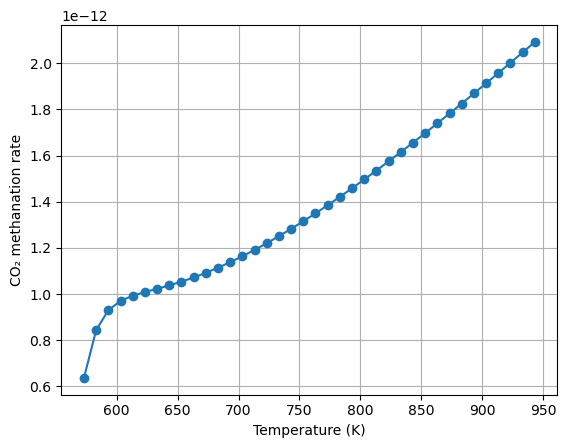

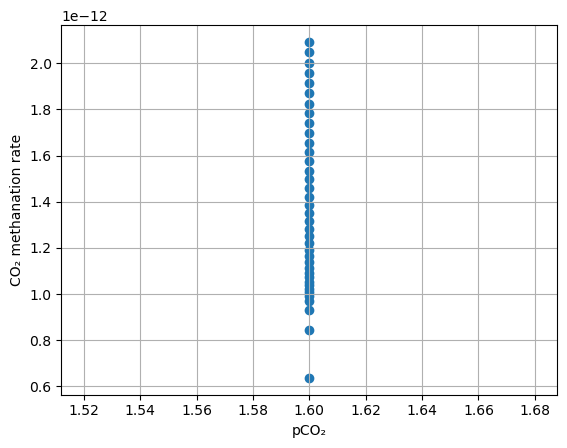

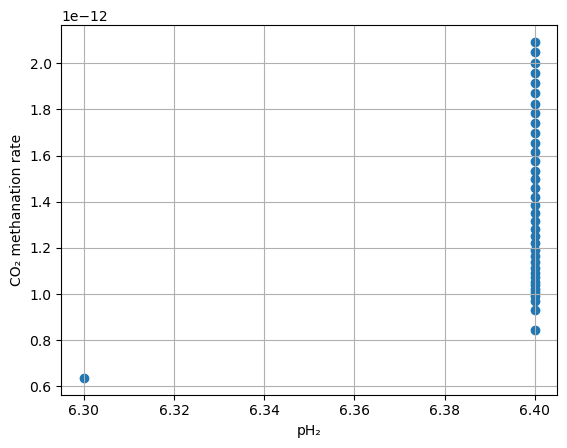

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# Constants
# ===============================
R = 8.314  # J/mol/K

# ===============================
# Read Excel
# ===============================
df = pd.read_excel("Dados_cinetica.xlsx", sheet_name="Champom")

# ===============================
# Normalize column names
# ===============================
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(" ", "", regex=False)
    .str.replace("_", "", regex=False)
    .str.lower()
)

print("Columns found:")
print(df.columns.tolist())

# ===============================
# Required columns (MATCHED)
# ===============================
needed = [
    "t",
    "ph2", "pco2", "pch4", "ph2o", "pco",
    "k0co2", "eaco2",
    "k0rswg", "earswg",
    "k0co", "eaco",
    "kads0co", "deltahco",
    "kads0h2", "deltahh2",
    "kads0h2o", "deltahh2o",
    "kads0co2", "deltahco2",
]

# ===============================
# Safe numeric conversion
# ===============================
def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(r"[^\d\.\-eE]", "", regex=True),
        errors="coerce"
    )

for c in needed:
    if c in df.columns:
        df[c] = clean_numeric(df[c])

print(f"✅ Numeric conversion done | Rows: {len(df)}")

# ===============================
# Champom kinetic model
# ===============================
def champom_rates(row):

    if row[needed].isna().any():
        return pd.Series([np.nan, np.nan, np.nan],
                         index=["rate_co2", "rate_rwgs", "rate_co"])

    T = row["t"]

    # Arrhenius constants
    kco2  = row["k0co2"]  * np.exp(-row["eaco2"]  / (R*T))
    krwgs = row["k0rswg"] * np.exp(-row["earswg"] / (R*T))
    kco   = row["k0co"]   * np.exp(-row["eaco"]   / (R*T))

    # Equilibrium constants
    keq_co2  = 137 * T**(-3.998) * np.exp(158700 / (R*T))
    keq_rwgs = 1 / (-3.732 + 2850/T + (470/T)**2)
    keq_co   = keq_co2 / keq_rwgs

    # Adsorption constants
    kco_ads  = row["kads0co"]  * np.exp(row["deltahco"]  / (R*T))
    kh2_ads  = row["kads0h2"]  * np.exp(row["deltahh2"]  / (R*T))
    kh2o_ads = row["kads0h2o"] * np.exp(row["deltahh2o"] / (R*T))
    kco2_ads = row["kads0co2"] * np.exp(row["deltahco2"] / (R*T))

    # Driving forces
    df_co2 = 1 - (row["pch4"] * row["ph2o"]**2) / (row["pco2"] * row["ph2"]**4 * keq_co2)
    df_rwgs = 1 - (row["pco"] * row["ph2o"]) / (row["pco2"] * row["ph2"] * keq_rwgs)
    df_co = 1 - (row["pch4"] * row["ph2o"]) / (row["pco"] * row["ph2"]**3 * keq_co)

    denom = (
        1
        + kh2_ads  * row["ph2"]
        + kco2_ads * row["pco2"]
        + kh2o_ads * row["ph2o"]
        + kco_ads  * row["pco"]
    )

    rate_co2  = kco2  * kh2_ads * kco2_ads * row["ph2"] * row["pco2"] * df_co2 / denom**2
    rate_rwgs = krwgs * row["pco2"] * kco2_ads * df_rwgs / denom
    rate_co   = kco   * row["ph2"] * row["pco"] * kh2_ads * kco_ads * df_co / denom**2

    return pd.Series([rate_co2, rate_rwgs, rate_co],
                     index=["rate_co2", "rate_rwgs", "rate_co"])

# ===============================
# Run model automatically
# ===============================
rates = df.apply(champom_rates, axis=1)
df = pd.concat([df, rates], axis=1)

print("✅ Rates calculated")

# ===============================
# Save results
# ===============================
with pd.ExcelWriter(
    "Dados_cinetica.xlsx",
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    df.to_excel(writer, sheet_name="Champom_Results", index=False)

print("✅ Results saved to Excel")

# ===============================
# Plots (comparison)
# ===============================
plt.figure()
plt.plot(df["t"], df["rate_co2"], "o-")
plt.xlabel("Temperature (K)")
plt.ylabel("CO₂ methanation rate")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(df["pco2"], df["rate_co2"])
plt.xlabel("pCO₂")
plt.ylabel("CO₂ methanation rate")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(df["ph2"], df["rate_co2"])
plt.xlabel("pH₂")
plt.ylabel("CO₂ methanation rate")
plt.grid(True)
plt.show()
